#CNN vs Transfer Learning untuk Klasifikasi Citra



## Identitas Mahasiswi
**Nama:** Amira Fathinah

**NIM:** 452024618075

**Prodi:** Teknik Informatika / 5

**Kelas:** C1

**Mata Kuliah:** Pembelajaran Mesin 2

##Bagian A: CNN from Scratch

###1. Import Library

Tahap pertama adalah mengimpor seluruh library yang dibutuhkan untuk proses pengolahan data, visualisasi, dan pembangunan model Convolutional Neural Network (CNN)

In [2]:
# Import Library
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


- Library NumPy digunakan untuk melakukan
manipulasi data numerik dan array multidimensi.
- Library Matplotlib digunakan untuk visualisasi data dan gambar.
- TensorFlow digunakan sebagai framework deep learning untuk membangun dan melatih model CNN.
- Dataset CIFAR-10 diambil dari modul tensorflow.keras.datasets sehingga proses pengunduhan dan pemanggilan dataset dapat dilakukan secara otomatis.

### 2. Memuat Dataset CIFAR-10

Dataset CIFAR-10 merupakan dataset klasifikasi citra yang berisi 60.000 gambar berwarna berukuran 32×32 piksel yang terbagi ke dalam 10 kelas objek. Dataset ini digunakan sebagai data awal untuk eksperimen CNN from Scratch.

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Shape x_train :", x_train.shape)
print("Shape y_train :", y_train.shape)

print("Shape x_test :", x_test.shape)
print("Shape y_test :", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Shape x_train : (50000, 32, 32, 3)
Shape y_train : (50000, 1)
Shape x_test : (10000, 32, 32, 3)
Shape y_test : (10000, 1)


Dataset CIFAR-10 terdiri atas dua bagian utama yaitu data pelatihan (training set) dan data pengujian (testing set). Data pelatihan berjumlah 50.000 gambar, sedangkan data pengujian berjumlah 10.000 gambar. Setiap gambar memiliki ukuran 32×32 piksel dengan tiga kanal warna (RGB). Bentuk data ini menunjukkan bahwa setiap sampel direpresentasikan sebagai tensor tiga dimensi yang sesuai untuk diproses menggunakan Convolutional Neural Network.

### 3. Menampilkan Informasi Kelas Dataset

Sebelum melakukan klasifikasi, perlu diketahui terlebih dahulu kategori objek yang tersedia pada dataset CIFAR-10. Informasi ini akan digunakan untuk memilih dua kelas yang akan digunakan pada eksperimen klasifikasi biner.

In [4]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

for i, name in enumerate(class_names):
    print(f"{i} : {name}")

0 : airplane
1 : automobile
2 : bird
3 : cat
4 : deer
5 : dog
6 : frog
7 : horse
8 : ship
9 : truck


Dataset CIFAR-10 memiliki sepuluh kategori objek, yaitu airplane, automobile, bird, cat, deer, dog, frog, horse, ship, dan truck. Pada eksperimen ini akan dipilih kelas cat dan dog yang masing-masing memiliki label 3 dan 5.

### 4. Visualisasi Sampel Dataset

Visualisasi dilakukan untuk memahami karakteristik gambar yang terdapat pada dataset serta memastikan bahwa data berhasil dimuat dengan benar.

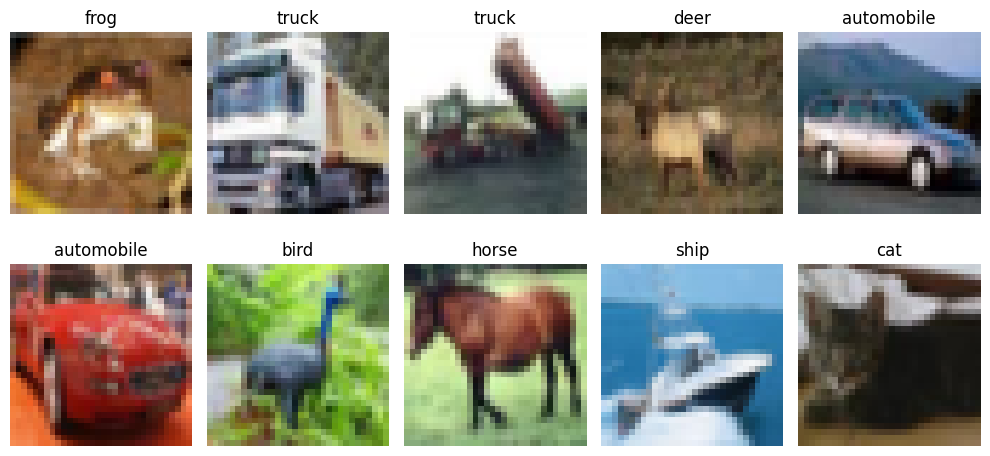

In [5]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

Visualisasi menunjukkan beberapa contoh gambar dari dataset CIFAR-10 beserta label kelasnya. Dari hasil visualisasi dapat diamati bahwa ukuran gambar relatif kecil, yaitu $32×32$ piksel, dengan variasi objek dan latar belakang yang cukup beragam. Tahap ini memperoleh pemahaman awal mengenai kompleksitas dataset sebelum dilakukan proses seleksi kelas, preprocessing, dan pelatihan model CNN.

###5. Seleksi Dua Kelas: Cat dan Dog

Dataset CIFAR-10 difilter agar hanya menyisakan dua kategori yang akan digunakan dalam eksperimen. Pada tahap ini dipilih kelas cat dan dog.

In [6]:
# Ambil hanya data dengan label cat (3) dan dog (5)
cat_label = 3
dog_label = 5

train_mask = np.where((y_train == cat_label) | (y_train == dog_label))[0]
test_mask = np.where((y_test == cat_label) | (y_test == dog_label))[0]

x_train_bin = x_train[train_mask]
y_train_bin = y_train[train_mask]
x_test_bin = x_test[test_mask]
y_test_bin = y_test[test_mask]

# Ubah label: cat = 0, dog = 1
y_train_bin = np.where(y_train_bin == cat_label, 0, 1)
y_test_bin = np.where(y_test_bin == cat_label, 0, 1)

print("Shape x_train_bin:", x_train_bin.shape)
print("Shape y_train_bin:", y_train_bin.shape)
print("Shape x_test_bin :", x_test_bin.shape)
print("Shape y_test_bin :", y_test_bin.shape)

Shape x_train_bin: (10000, 32, 32, 3)
Shape y_train_bin: (10000, 1)
Shape x_test_bin : (2000, 32, 32, 3)
Shape y_test_bin : (2000, 1)


Setelah dilakukan filtering, dataset hanya berisi dua kelas yang relevan untuk eksperimen klasifikasi biner. Label cat diubah menjadi 0 dan label dog diubah menjadi 1 agar format label lebih sesuai untuk proses training model klasifikasi biner. Tahap ini penting karena model CNN yang dibangun nanti hanya akan belajar membedakan dua kategori tersebut, bukan seluruh sepuluh kelas pada CIFAR-10.

###6. Distribusi Data per Kelas

Sebelum masuk ke preprocessing, perlu diperiksa jumlah sampel pada masing-masing kelas. Hal ini dilakukan untuk memastikan bahwa dataset yang digunakan relatif seimbang dan tidak menimbulkan bias yang besar pada proses pelatihan model.

In [7]:
unique_train, counts_train = np.unique(y_train_bin, return_counts=True)
unique_test, counts_test = np.unique(y_test_bin, return_counts=True)

print("Distribusi data training:")
for label, count in zip(unique_train, counts_train):
    print(f"Kelas {label} : {count} gambar")

print("\nDistribusi data testing:")
for label, count in zip(unique_test, counts_test):
    print(f"Kelas {label} : {count} gambar")

Distribusi data training:
Kelas 0 : 5000 gambar
Kelas 1 : 5000 gambar

Distribusi data testing:
Kelas 0 : 1000 gambar
Kelas 1 : 1000 gambar


Hasil perhitungan distribusi data menunjukkan jumlah gambar untuk setiap kelas pada data training dan testing. Informasi ini berguna untuk mengevaluasi keseimbangan dataset. Jika jumlah kedua kelas relatif sama, maka model tidak akan terlalu bias terhadap salah satu kelas.

###7. Visualisasi Sampel Kelas Cat dan Dog

Visualisasi sampel dilakukan untuk memastikan bahwa data yang telah difilter benar-benar hanya berisi dua kelas yang diinginkan. Selain itu, tahap ini membantu memahami karakteristik visual dari kedua kelas sebelum proses preprocessing dilakukan.

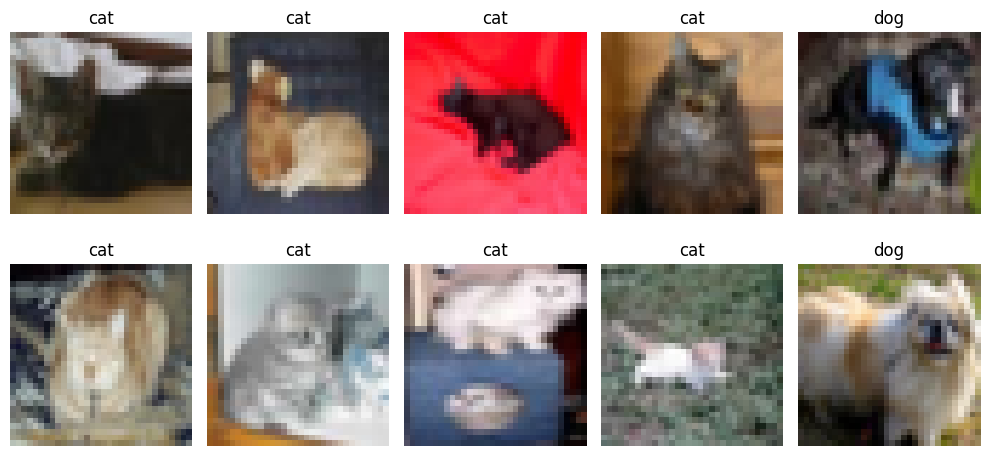

In [8]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_bin[i])
    plt.title("cat" if y_train_bin[i][0] == 0 else "dog")
    plt.axis('off')

plt.tight_layout()
plt.show()

Visualisasi ini memperlihatkan contoh gambar dari dua kelas yang akan digunakan dalam eksperimen CNN from Scratch. Dari tampilan gambar dapat diamati bahwa objek memiliki variasi pose, warna, dan latar belakang yang berbeda-beda. Karakteristik tersebut cukup penting karena akan memengaruhi tingkat kesulitan model dalam mempelajari pola visual yang membedakan cat dan dog.

### 8. Pembagian Data Menjadi Training, Validation, dan Testing

Setelah dataset difilter menjadi dua kelas, data perlu dibagi kembali menjadi tiga bagian, yaitu data training, validation, dan testing. Pembagian ini penting agar model dilatih pada data training, disetel menggunakan data validation, dan dievaluasi secara objektif pada data testing yang belum pernah dilihat sebelumnya.

In [9]:
from sklearn.model_selection import train_test_split

# Gabungkan seluruh data cat dan dog
x_all = np.concatenate([x_train_bin, x_test_bin], axis=0)
y_all = np.concatenate([y_train_bin, y_test_bin], axis=0)

# Split awal: 70% train, 30% sisa
x_train_final, x_temp, y_train_final, y_temp = train_test_split(
    x_all,
    y_all,
    test_size=0.30,
    random_state=42,
    stratify=y_all
)

# Split sisa 30% menjadi 15% validation dan 15% testing
x_val_final, x_test_final, y_val_final, y_test_final = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Shape x_train_final :", x_train_final.shape)
print("Shape y_train_final :", y_train_final.shape)
print("Shape x_val_final    :", x_val_final.shape)
print("Shape y_val_final    :", y_val_final.shape)
print("Shape x_test_final   :", x_test_final.shape)
print("Shape y_test_final   :", y_test_final.shape)

Shape x_train_final : (8400, 32, 32, 3)
Shape y_train_final : (8400, 1)
Shape x_val_final    : (1800, 32, 32, 3)
Shape y_val_final    : (1800, 1)
Shape x_test_final   : (1800, 32, 32, 3)
Shape y_test_final   : (1800, 1)


Pada tahap ini seluruh data cat dan dog digabung terlebih dahulu, lalu dibagi kembali menjadi tiga subset dengan proporsi 70% untuk training, 15% untuk validation, dan 15% untuk testing. Teknik stratify digunakan agar proporsi kedua kelas tetap seimbang pada setiap subset, sehingga model tidak belajar dari distribusi kelas yang bias. Pembagian seperti ini sangat penting karena validation set digunakan untuk memantau performa selama training, sedangkan test set dipakai sebagai ukuran akhir kemampuan generalisasi model.

### 9. Normalisasi Data

Sebelum digunakan untuk pelatihan model, data gambar perlu dinormalisasi agar nilai piksel berada pada skala yang lebih kecil dan konsisten. Normalisasi membantu proses optimasi menjadi lebih stabil dan mempercepat konvergensi model CNN.

In [10]:
# Ubah tipe data menjadi float32 dan skala piksel ke rentang 0-1
x_train_final = x_train_final.astype("float32") / 255.0
x_val_final = x_val_final.astype("float32") / 255.0
x_test_final = x_test_final.astype("float32") / 255.0

print("Range nilai piksel training:", x_train_final.min(), "sampai", x_train_final.max())

Range nilai piksel training: 0.0 sampai 1.0


Normalisasi dilakukan dengan membagi seluruh nilai piksel dengan 255 sehingga nilainya berubah dari rentang $0–255$ menjadi $0–1$. Langkah ini membuat input lebih mudah diproses oleh jaringan saraf dan biasanya menghasilkan training yang lebih stabil. Selain itu, normalisasi juga membantu mengurangi masalah gradien yang terlalu besar ketika model sedang belajar.

### 10. Menyiapkan Label untuk Klasifikasi Biner

Karena eksperimen ini hanya menggunakan dua kelas, label harus dipastikan dalam format yang sesuai untuk klasifikasi biner. Pada tahap ini label cat dipertahankan sebagai 0 dan label dog sebagai 1.

In [11]:
# Pastikan label berbentuk array 1 dimensi
y_train_final = y_train_final.flatten()
y_val_final = y_val_final.flatten()
y_test_final = y_test_final.flatten()

print("Unique label training :", np.unique(y_train_final))
print("Unique label validation:", np.unique(y_val_final))
print("Unique label testing   :", np.unique(y_test_final))

Unique label training : [0 1]
Unique label validation: [0 1]
Unique label testing   : [0 1]


Label pada tahap ini dibuat dalam bentuk satu dimensi agar sesuai dengan format yang dibutuhkan oleh model klasifikasi biner. Penyederhanaan label menjadi 0 dan 1 juga memudahkan proses training, evaluasi, dan interpretasi hasil prediksi. Dengan demikian, model hanya fokus mempelajari perbedaan visual antara cat dan dog.

### 11. Membangun Arsitektur CNN from Scratch

Arsitektur CNN disusun untuk menangkap pola visual bertingkat, mulai dari fitur sederhana seperti tepi dan tekstur, hingga fitur yang lebih kompleks untuk membedakan kelas cat dan dog.

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,545 (1.36 MB)

 Trainable params: 356,097 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

Arsitektur CNN ini terdiri dari tiga lapisan convolution yang masing-masing diikuti oleh batch normalization dan max pooling.

**Lapisan convolution** berfungsi mengekstraksi fitur visual, sedangkan **max pooling** membantu mengurangi dimensi data agar komputasi lebih efisien. Penggunaan **activation ReLU** dipilih karena mampu mempercepat proses pembelajaran dan mengurangi masalah vanishing gradient. Setelah fitur visual diekstraksi, hasilnya diratakan menggunakan flatten, lalu diteruskan ke dense layer untuk melakukan klasifikasi akhir. Dropout ditambahkan untuk membantu mengurangi risiko overfitting, sedangkan layer output menggunakan aktivasi sigmoid karena tugas ini adalah klasifikasi biner.

### 12. Mengompilasi Model CNN

Setelah arsitektur model dibangun, model perlu dikompilasi dengan memilih fungsi loss, optimizer, dan metrik evaluasi. Tahap ini menentukan bagaimana model akan belajar dari data training.

In [13]:
model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Model dikompilasi menggunakan optimizer Adam karena optimizer ini umumnya stabil dan efektif untuk tugas klasifikasi citra. Learning rate sebesar 0.001 dipilih sebagai nilai awal yang cukup umum untuk eksperimen CNN from Scratch. Fungsi loss binary crossentropy digunakan karena model hanya membedakan dua kelas, sedangkan metrik accuracy dipakai untuk melihat performa klasifikasi secara langsung selama training dan evaluasi.

### 13. Melatih Model CNN

Tahap berikutnya adalah melatih model menggunakan data training dan memantau performanya melalui data validation. Proses ini menghasilkan riwayat training yang nanti digunakan untuk visualisasi akurasi dan loss.

In [14]:
history_cnn = model_cnn.fit(
    x_train_final,
    y_train_final,
    validation_data=(x_val_final, y_val_final),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 34s 105ms/step - accuracy: 0.6092 - loss: 0.7086 - val_accuracy: 0.5328 - val_loss: 1.1190
Epoch 2/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 32s 123ms/step - accuracy: 0.6800 - loss: 0.5947 - val_accuracy: 0.6244 - val_loss: 0.6344
Epoch 3/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 31s 117ms/step - accuracy: 0.7269 - loss: 0.5438 - val_accuracy: 0.6667 - val_loss: 0.6444
Epoch 4/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 40s 115ms/step - accuracy: 0.7554 - loss: 0.5016 - val_accuracy: 0.7572 - val_loss: 0.5076
Epoch 5/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 40s 112ms/step - accuracy: 0.7755 - loss: 0.4591 - val_accuracy: 0.7156 - val_loss: 0.5299
Epoch 6/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 38s 100ms/step - accuracy: 0.7988 - loss: 0.4196 - val_accuracy: 0.7578 - val_loss: 0.4875
Epoch 7/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 27s 103ms/step - accuracy: 0.8213 - loss: 0.3875 - val_accuracy: 0.7367 - val_loss: 0.6019
Epoch 8/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 29s 112ms/step - accuracy: 0.8536 - loss: 0

Model dilatih selama 20 epoch dengan batch size 32. Jumlah epoch ini masih bisa disesuaikan berdasarkan hasil training, misalnya jika model belum konvergen atau justru mulai overfitting. Data validation digunakan selama training agar kita bisa memantau apakah model benar-benar belajar dengan baik atau hanya menghafal data training.

### 14. Evaluasi Awal Model CNN

Setelah proses training selesai, model diuji menggunakan data testing untuk memperoleh gambaran kemampuan generalisasi model terhadap data yang belum pernah dilihat sebelumnya.

In [15]:
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(x_test_final, y_test_final, verbose=0)

print("Test Loss CNN :", test_loss_cnn)
print("Test Accuracy CNN :", test_acc_cnn)

Test Loss CNN : 1.2913576364517212
Test Accuracy CNN : 0.7788888812065125


Evaluasi pada data testing memberikan hasil yang lebih objektif dibandingkan hanya melihat training accuracy. Jika performa pada testing jauh lebih rendah dibandingkan training, maka model kemungkinan mengalami overfitting. Hasil evaluasi ini akan menjadi dasar untuk analisis performa CNN from Scratch pada laporan akhir.

### 15. Visualisasi Akurasi dan Loss CNN

Grafik akurasi dan loss digunakan untuk menganalisis proses pembelajaran model selama training. Visualisasi ini penting untuk melihat apakah model mengalami peningkatan performa atau justru overfitting.

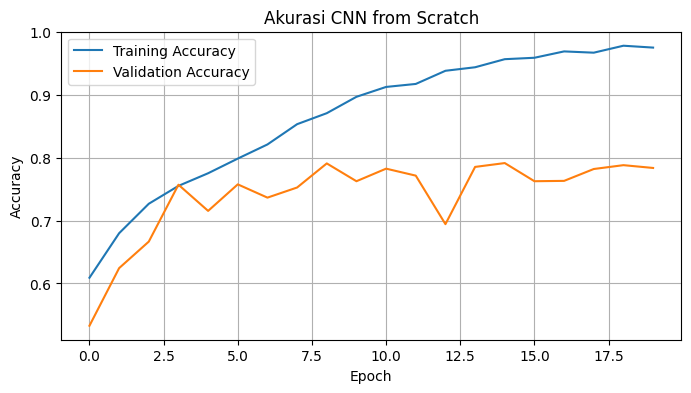

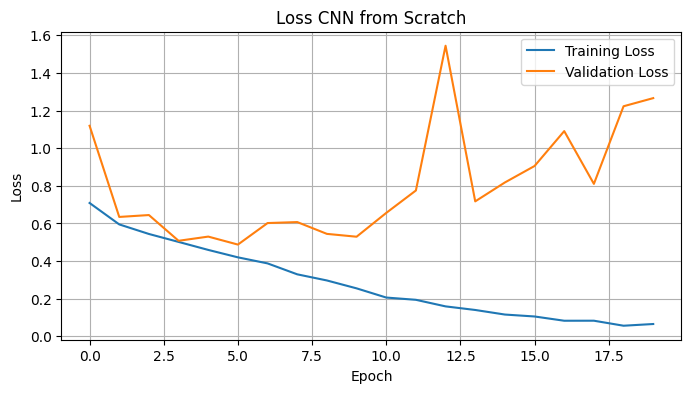

In [16]:
# Plot akurasi
plt.figure(figsize=(8, 4))
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Akurasi CNN from Scratch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot loss
plt.figure(figsize=(8, 4))
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('Loss CNN from Scratch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Grafik akurasi menunjukkan perkembangan kemampuan model dalam mengenali kelas cat dan dog selama training. Jika akurasi training terus naik tetapi akurasi validation stagnan atau turun, maka model cenderung overfitting. Grafik loss membantu memperkuat analisis tersebut karena peningkatan loss pada validation set juga menandakan bahwa model tidak lagi mampu melakukan generalisasi dengan baik. Kedua grafik ini sangat penting untuk dimasukkan ke dalam laporan eksperimen.

### 16. Confusion Matrix untuk CNN from Scratch

Confusion matrix digunakan untuk melihat secara rinci jumlah prediksi benar dan salah pada masing-masing kelas. Dengan visualisasi ini, kita dapat mengetahui apakah model lebih sering salah mengklasifikasikan cat sebagai dog atau sebaliknya.

57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step


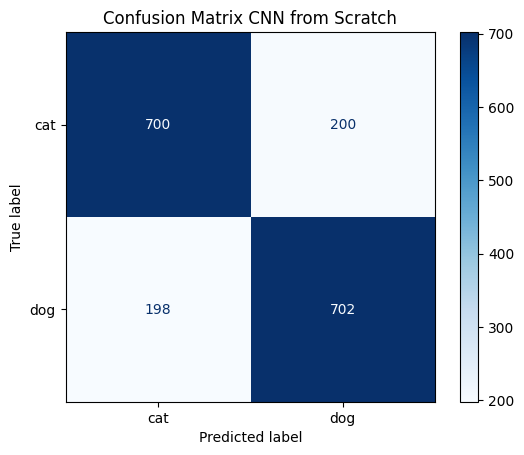

Confusion Matrix CNN:
[[700 200]
 [198 702]]


In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Prediksi pada data test
y_pred_prob_cnn = model_cnn.predict(x_test_final)
y_pred_cnn = (y_pred_prob_cnn > 0.5).astype(int).flatten()

# Confusion matrix
cm_cnn = confusion_matrix(y_test_final, y_pred_cnn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=['cat', 'dog'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix CNN from Scratch')
plt.show()

print("Confusion Matrix CNN:")
print(cm_cnn)

Confusion matrix menunjukkan performa model secara lebih detail dibandingkan hanya melihat accuracy. Nilai pada diagonal utama merepresentasikan prediksi yang benar, sedangkan nilai di luar diagonal menunjukkan kesalahan klasifikasi. Dari matriks ini kita dapat menilai apakah model lebih baik mengenali salah satu kelas dibandingkan kelas lainnya, serta mengamati pola kesalahan yang mungkin terjadi.

### 17. Contoh Prediksi Benar dan Salah pada CNN from Scratch

Selain confusion matrix, contoh prediksi benar dan salah membantu memahami secara visual bagaimana model bekerja pada data yang belum pernah dilihat sebelumnya.

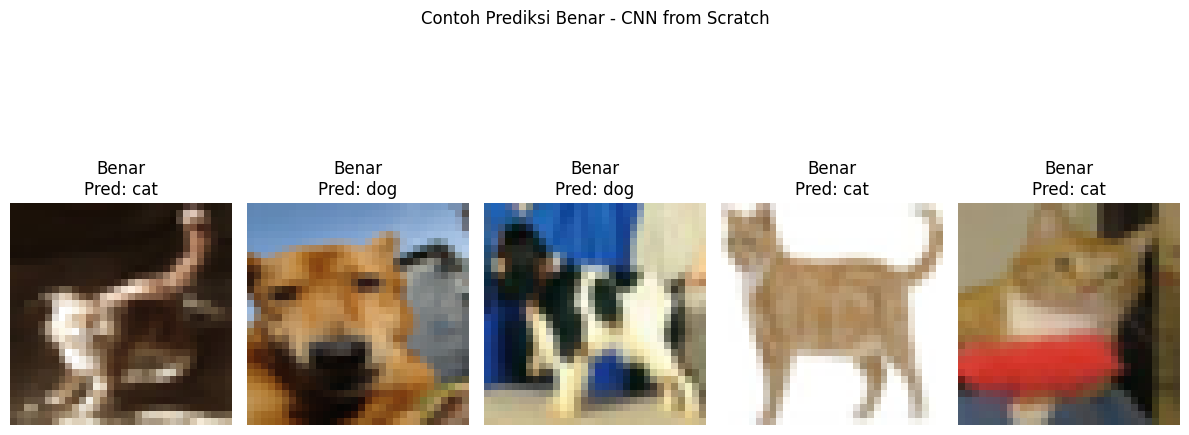

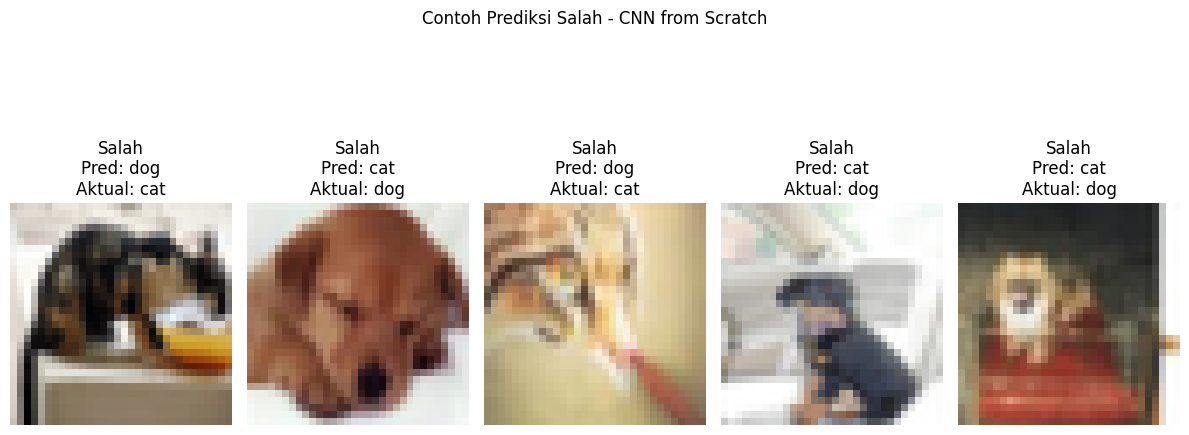

In [18]:
# Ambil nama kelas
label_names = {0: 'cat', 1: 'dog'}

# Cari indeks prediksi benar dan salah
correct_idx = np.where(y_pred_cnn == y_test_final)[0]
wrong_idx = np.where(y_pred_cnn != y_test_final)[0]

# Tampilkan beberapa contoh benar
plt.figure(figsize=(12, 6))
for i, idx in enumerate(correct_idx[:5]):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test_final[idx])
    plt.title(f"Benar\nPred: {label_names[y_pred_cnn[idx]]}")
    plt.axis('off')
plt.suptitle("Contoh Prediksi Benar - CNN from Scratch")
plt.tight_layout()
plt.show()

# Tampilkan beberapa contoh salah
plt.figure(figsize=(12, 6))
for i, idx in enumerate(wrong_idx[:5]):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test_final[idx])
    plt.title(f"Salah\nPred: {label_names[y_pred_cnn[idx]]}\nAktual: {label_names[y_test_final[idx]]}")
    plt.axis('off')
plt.suptitle("Contoh Prediksi Salah - CNN from Scratch")
plt.tight_layout()
plt.show()

Contoh prediksi benar memperlihatkan gambar-gambar yang berhasil dikenali model dengan tepat, sedangkan contoh prediksi salah menunjukkan kasus-kasus yang masih sulit dibedakan oleh model. Analisis visual seperti ini penting karena membantu menjelaskan kelemahan model secara konkret, misalnya ketika bentuk objek, pose, latar belakang, atau pencahayaan membuat model tertukar antara cat dan dog.

##Bagian B: Transfer Learning (Cat vs Dog)

### 1. Import Library

Pada tahap ini dilakukan impor library yang dibutuhkan untuk mengakses dataset dari Kaggle, melakukan preprocessing citra, serta membangun model transfer learning menggunakan pretrained model.

In [19]:
!pip install -q kagglehub

import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

Library **KaggleHub** digunakan untuk mengunduh dataset langsung dari Kaggle tanpa perlu melakukan download manual. Selain itu, **TensorFlow** digunakan untuk membangun model deep learning dan melakukan preprocessing data citra.

### 2. Mengunduh Dataset Cats vs Dogs

Dataset Cats vs Dogs digunakan sebagai dataset pada eksperimen transfer learning. Dataset ini berisi gambar kucing dan anjing dengan variasi pose, warna, ukuran, dan latar belakang yang cukup beragam.

In [20]:
path = kagglehub.dataset_download(
    "shaunthesheep/microsoft-catsvsdogs-dataset"
)

print("Dataset path:", path)

Using Colab cache for faster access to the 'microsoft-catsvsdogs-dataset' dataset.
Dataset path: /kaggle/input/microsoft-catsvsdogs-dataset


Dataset diunduh langsung dari Kaggle menggunakan KaggleHub. Setelah proses pengunduhan selesai, dataset akan tersimpan secara otomatis pada direktori lokal notebook dan siap digunakan untuk proses selanjutnya.

### 3. Mengeksplorasi Struktur Dataset

Sebelum melakukan preprocessing, perlu dilakukan pemeriksaan struktur folder dataset untuk mengetahui lokasi penyimpanan gambar kucing dan anjing.

In [21]:
for root, dirs, files in os.walk(path):
    print(root)
    break

/kaggle/input/microsoft-catsvsdogs-dataset


Pemeriksaan struktur folder dilakukan untuk memastikan lokasi dataset dan memahami bagaimana gambar disusun. Informasi ini diperlukan untuk menentukan direktori yang akan digunakan saat proses loading data.

### 4. Menentukan Path Folder Dataset

In [22]:
# Path dasar dataset dari KaggleHub
base_path = path

# Folder gambar cat dan dog
cat_dir = os.path.join(base_path, "PetImages", "Cat")
dog_dir = os.path.join(base_path, "PetImages", "Dog")

print("Folder Cat :", cat_dir)
print("Folder Dog :", dog_dir)

Folder Cat : /kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Cat
Folder Dog : /kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Dog


### 5. Membuat Daftar File Gambar dan Memeriksa Gambar Rusak

Sebelum data digunakan untuk training, setiap file gambar perlu dicek terlebih dahulu agar hanya gambar yang valid yang masuk ke dataset. Langkah ini penting karena dataset dari Kaggle terkadang berisi file yang corrupt atau tidak bisa dibaca oleh library pemrosesan gambar.

In [23]:
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split

# Ambil semua file gambar dari folder Cat dan Dog
cat_files = [
    os.path.join(cat_dir, f)
    for f in os.listdir(cat_dir)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

dog_files = [
    os.path.join(dog_dir, f)
    for f in os.listdir(dog_dir)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

print("Jumlah file Cat:", len(cat_files))
print("Jumlah file Dog:", len(dog_files))

# Fungsi untuk memeriksa file gambar yang valid
def filter_valid_images(file_list):
    valid_files = []
    invalid_files = []

    for fp in file_list:
        try:
            with Image.open(fp) as img:
                img.verify()
            valid_files.append(fp)
        except Exception:
            invalid_files.append(fp)

    return valid_files, invalid_files

valid_cat, invalid_cat = filter_valid_images(cat_files)
valid_dog, invalid_dog = filter_valid_images(dog_files)

print("\nJumlah gambar Cat valid   :", len(valid_cat))
print("Jumlah gambar Cat corrupt :", len(invalid_cat))
print("Jumlah gambar Dog valid   :", len(valid_dog))
print("Jumlah gambar Dog corrupt :", len(invalid_dog))

# Buat dataframe gabungan
df = pd.DataFrame({
    "filepath": valid_cat + valid_dog,
    "label": [0] * len(valid_cat) + [1] * len(valid_dog)
})

# Acak urutan data
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nContoh isi dataframe:")
print(df.head())

Jumlah file Cat: 12500
Jumlah file Dog: 12500


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))



Jumlah gambar Cat valid   : 12499
Jumlah gambar Cat corrupt : 1
Jumlah gambar Dog valid   : 12499
Jumlah gambar Dog corrupt : 1

Contoh isi dataframe:
                                            filepath  label
0  /kaggle/input/microsoft-catsvsdogs-dataset/Pet...      0
1  /kaggle/input/microsoft-catsvsdogs-dataset/Pet...      1
2  /kaggle/input/microsoft-catsvsdogs-dataset/Pet...      0
3  /kaggle/input/microsoft-catsvsdogs-dataset/Pet...      1
4  /kaggle/input/microsoft-catsvsdogs-dataset/Pet...      1


Tahap ini menghasilkan daftar file gambar yang sudah dipastikan dapat dibaca dengan benar. Proses verifikasi ini sangat penting karena file yang corrupt dapat menyebabkan error saat training atau membuat proses pembacaan data berhenti di tengah jalan. Setelah gambar valid dikumpulkan, data digabung ke dalam sebuah dataframe yang berisi lokasi file dan label kelas, yaitu 0 untuk cat dan 1 untuk dog. Data kemudian diacak agar distribusi kelas lebih merata sebelum dibagi menjadi training, validation, dan testing.

### 6. Pembagian Dataset Menjadi Training, Validation, dan Testing

Setelah daftar gambar valid berhasil dikumpulkan, data dibagi menjadi tiga subset, yaitu training, validation, dan testing. Pembagian ini diperlukan agar model dilatih pada data training, dipantau performanya menggunakan validation set, dan diuji secara objektif pada test set yang benar-benar baru.

In [24]:
from sklearn.model_selection import train_test_split

# Split awal: 70% training dan 30% sementara
df_train, df_temp = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

# Split sementara: 15% validation dan 15% testing
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    random_state=42,
    stratify=df_temp["label"]
)

print("Jumlah data training   :", len(df_train))
print("Jumlah data validation :", len(df_val))
print("Jumlah data testing    :", len(df_test))

print("\nDistribusi label training:")
print(df_train["label"].value_counts().sort_index())

print("\nDistribusi label validation:")
print(df_val["label"].value_counts().sort_index())

print("\nDistribusi label testing:")
print(df_test["label"].value_counts().sort_index())

Jumlah data training   : 17498
Jumlah data validation : 3750
Jumlah data testing    : 3750

Distribusi label training:
label
0    8749
1    8749
Name: count, dtype: int64

Distribusi label validation:
label
0    1875
1    1875
Name: count, dtype: int64

Distribusi label testing:
label
0    1875
1    1875
Name: count, dtype: int64


Pembagian data dilakukan dengan proporsi 70% untuk training, 15% untuk validation, dan 15% untuk testing. Parameter stratify digunakan agar proporsi kelas cat dan dog tetap seimbang pada setiap subset. Hal ini penting karena model klasifikasi biner sangat sensitif terhadap distribusi kelas, sehingga pembagian yang tidak seimbang dapat membuat evaluasi menjadi bias dan performa model terlihat lebih baik atau lebih buruk dari kondisi sebenarnya.

### 7. Memeriksa Hasil Pembagian Data

Setelah data dibagi ke dalam tiga subset, perlu dilakukan pengecekan singkat untuk memastikan bahwa setiap subset sudah terbentuk dengan benar dan masih mewakili dua kelas yang digunakan dalam eksperimen.

In [25]:
# Tampilkan beberapa sampel dari masing-masing subset
print("Contoh data training:")
print(df_train.head(), "\n")

print("Contoh data validation:")
print(df_val.head(), "\n")

print("Contoh data testing:")
print(df_test.head())

Contoh data training:
                                                filepath  label
24490  /kaggle/input/microsoft-catsvsdogs-dataset/Pet...      1
13311  /kaggle/input/microsoft-catsvsdogs-dataset/Pet...      0
18866  /kaggle/input/microsoft-catsvsdogs-dataset/Pet...      0
14063  /kaggle/input/microsoft-catsvsdogs-dataset/Pet...      0
17512  /kaggle/input/microsoft-catsvsdogs-dataset/Pet...      1 

Contoh data validation:
                                                filepath  label
1234   /kaggle/input/microsoft-catsvsdogs-dataset/Pet...      1
19736  /kaggle/input/microsoft-catsvsdogs-dataset/Pet...      0
20542  /kaggle/input/microsoft-catsvsdogs-dataset/Pet...      0
6610   /kaggle/input/microsoft-catsvsdogs-dataset/Pet...      0
13082  /kaggle/input/microsoft-catsvsdogs-dataset/Pet...      1 

Contoh data testing:
                                                filepath  label
21986  /kaggle/input/microsoft-catsvsdogs-dataset/Pet...      1
19762  /kaggle/input/microsoft-ca

Pengecekan ini dilakukan untuk memastikan bahwa hasil pembagian data sudah sesuai dan setiap subset berisi data yang valid. Tahap ini juga membantu mengurangi risiko kesalahan saat proses loading gambar nantinya, karena kita sudah mengetahui struktur data yang akan diproses oleh model transfer learning.

### 8. Membuat Data Generator untuk Preprocessing dan Augmentasi

Pada tahap ini dibuat data generator untuk membaca gambar langsung dari file path, melakukan resize otomatis, normalisasi, dan augmentasi data. Langkah ini sangat penting dalam transfer learning karena pretrained model biasanya membutuhkan ukuran input tertentu, dan augmentasi membantu model lebih tahan terhadap variasi gambar.

In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Convert labels to string type for flow_from_dataframe with class_mode="binary"
df_train['label'] = df_train['label'].astype(str)
df_val['label'] = df_val['label'].astype(str)
df_test['label'] = df_test['label'].astype(str)

# Data augmentation untuk training
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

# Hanya preprocessing untuk validation dan testing
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=42
)

val_generator = test_datagen.flow_from_dataframe(
    dataframe=df_val,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=df_test,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 17498 validated image filenames belonging to 2 classes.
Found 3750 validated image filenames belonging to 2 classes.
Found 3750 validated image filenames belonging to 2 classes.


Data generator digunakan agar gambar dapat dibaca langsung dari path file tanpa perlu dimuat semuanya ke memori sekaligus. Pada data training, augmentation diterapkan untuk menambah variasi data secara sintetik, misalnya melalui rotasi, pergeseran, zoom, dan flip horizontal. Teknik ini membantu model belajar lebih robust dan mengurangi risiko overfitting. Untuk validation dan testing, hanya preprocessing dasar yang digunakan karena kedua subset tersebut harus merepresentasikan data asli tanpa modifikasi tambahan. Selain itu, fungsi `preprocess_input` dari MobileNetV2 digunakan agar format nilai piksel sesuai dengan kebutuhan pretrained model yang akan dipakai pada tahap transfer learning.

### 9. Menampilkan Contoh Gambar Setelah Preprocessing

Sebelum model dilatih, perlu dicek terlebih dahulu apakah hasil preprocessing dan augmentasi sudah berjalan dengan benar. Visualisasi ini membantu memastikan bahwa gambar telah terbaca dalam ukuran yang sesuai untuk pretrained model.

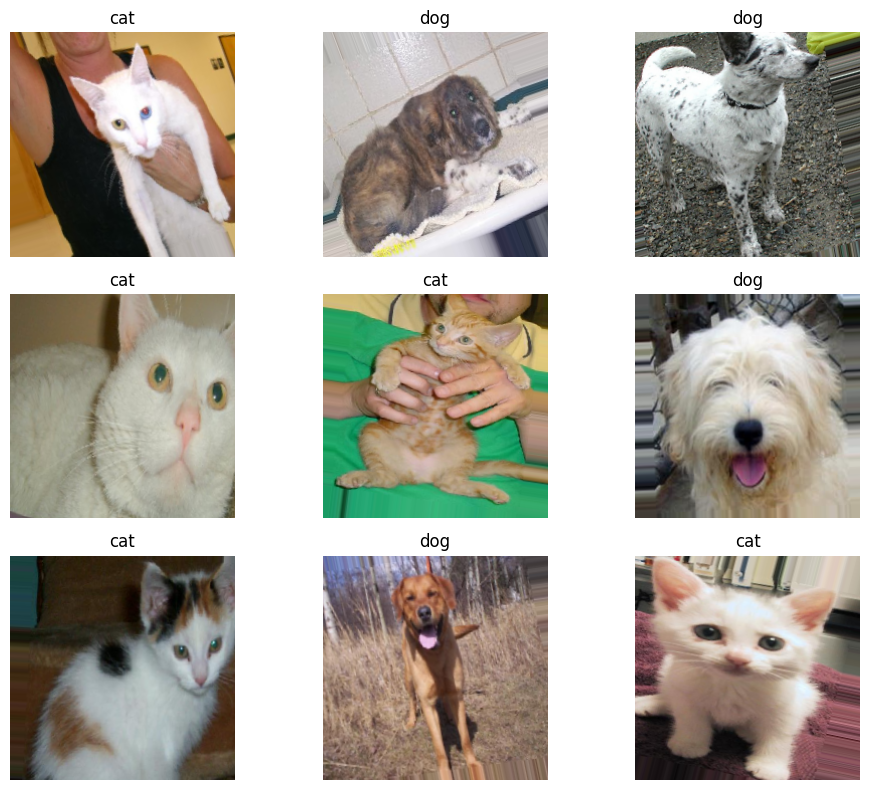

In [28]:
# Ambil satu batch data dari generator
images, labels = next(train_generator)

plt.figure(figsize=(10, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    img = images[i].astype("float32")

    # Karena preprocess_input MobileNetV2 mengubah skala,
    # gambar ditampilkan kembali secara sederhana untuk pengecekan visual
    img_display = (img + 1.0) / 2.0
    img_display = np.clip(img_display, 0, 1)

    plt.imshow(img_display)
    plt.title("cat" if labels[i] == 0 else "dog")
    plt.axis("off")

plt.tight_layout()
plt.show()

Visualisasi ini digunakan untuk memeriksa apakah gambar telah berhasil diproses oleh generator. Karena MobileNetV2 menggunakan preprocessing khusus, nilai piksel pada gambar mengalami transformasi sebelum masuk ke model. Dengan melihat contoh hasil preprocessing, kita dapat memastikan bahwa data yang digunakan sudah sesuai dengan ukuran input dan format yang dibutuhkan oleh pretrained model.

### 10. Membangun Model Transfer Learning dengan MobileNetV2

Pada tahap ini dibangun model transfer learning menggunakan MobileNetV2 sebagai pretrained model. Lapisan utama MobileNetV2 digunakan sebagai feature extractor, sedangkan bagian classifier disusun ulang agar sesuai dengan tugas klasifikasi biner antara cat dan dog.

In [29]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout

# Load pretrained model tanpa top layer bawaan
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Membekukan seluruh layer pretrained model
base_model.trainable = False

# Membangun classifier baru di atas base model
inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model_tl = Model(inputs, outputs)

model_tl.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

MobileNetV2 dipilih karena merupakan pretrained model yang relatif ringan, cepat, dan cukup efisien untuk dijalankan. Lapisan awal MobileNetV2 telah mempelajari fitur visual umum dari ImageNet, seperti tepi, tekstur, dan pola bentuk, sehingga layer-layer tersebut dapat dimanfaatkan kembali untuk tugas klasifikasi cat dan dog. Pada tahap ini seluruh layer pretrained dibekukan terlebih dahulu agar model hanya melatih classifier baru di atasnya. Pendekatan ini dikenal sebagai feature extraction dan biasanya cocok ketika dataset tidak terlalu besar atau ketika ingin mendapatkan baseline performa dengan cepat.

### 11. Mengompilasi Model Transfer Learning

Setelah arsitektur transfer learning selesai dibangun, model perlu dikompilasi menggunakan fungsi loss, optimizer, dan metrik evaluasi yang sesuai dengan klasifikasi biner.

In [30]:
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Model transfer learning dikompilasi menggunakan Adam optimizer karena optimizer ini stabil dan umum digunakan pada klasifikasi citra. Fungsi loss binary crossentropy dipilih karena eksperimen ini hanya melibatkan dua kelas, yaitu cat dan dog. Metrik accuracy digunakan untuk memantau performa klasifikasi selama proses training dan evaluasi.

### 12. Melatih Model Transfer Learning

Pada tahap ini model transfer learning dilatih menggunakan data training dan divalidasi menggunakan validation set. Hasil training akan disimpan dalam history untuk dianalisis melalui grafik akurasi dan loss.

In [31]:
history_tl = model_tl.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    verbose=1
)

Epoch 1/10
185/547 ━━━━━━━━━━━━━━━━━━━━ 10:54 2s/step - accuracy: 0.9313 - loss: 0.1657

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


547/547 ━━━━━━━━━━━━━━━━━━━━ 1076s 2s/step - accuracy: 0.9699 - loss: 0.0816 - val_accuracy: 0.9864 - val_loss: 0.0363
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 1013s 2s/step - accuracy: 0.9779 - loss: 0.0581 - val_accuracy: 0.9896 - val_loss: 0.0243
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 1066s 2s/step - accuracy: 0.9797 - loss: 0.0526 - val_accuracy: 0.9904 - val_loss: 0.0248
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 1128s 2s/step - accuracy: 0.9813 - loss: 0.0490 - val_accuracy: 0.9920 - val_loss: 0.0232
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 1093s 2s/step - accuracy: 0.9814 - loss: 0.0467 - val_accuracy: 0.9867 - val_loss: 0.0302
Epoch 6/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 1054s 2s/step - accuracy: 0.9833 - loss: 0.0438 - val_accuracy: 0.9899 - val_loss: 0.0251
Epoch 7/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 1038s 2s/step - accuracy: 0.9845 - loss: 0.0422 - val_accuracy: 0.9891 - val_loss: 0.0284
Epoch 8/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 1025s 2s/step - accuracy: 0.9835 - loss: 0.0428 - val_accurac

Model dilatih menggunakan data generator agar gambar diproses secara otomatis selama training. Jumlah epoch dapat disesuaikan berdasarkan hasil eksperimen, tetapi pada tahap awal 10 epoch sudah cukup untuk melihat pola performa model. Validation data digunakan untuk memantau apakah model benar-benar belajar dengan baik atau mulai menunjukkan tanda overfitting.

### 13. Evaluasi Model Transfer Learning

Setelah training selesai, model dievaluasi pada data testing untuk mengukur kemampuan generalisasi terhadap data yang belum pernah dilihat sebelumnya.

In [32]:
test_loss_tl, test_acc_tl = model_tl.evaluate(test_generator, verbose=0)

print("Test Loss Transfer Learning :", test_loss_tl)
print("Test Accuracy Transfer Learning :", test_acc_tl)

Test Loss Transfer Learning : 0.03081938996911049
Test Accuracy Transfer Learning : 0.9890666604042053


Evaluasi pada test set memberikan gambaran yang lebih objektif tentang performa model dibandingkan hanya melihat hasil training. Jika nilai akurasi testing cukup tinggi dan loss testing tidak terlalu jauh dari validation loss, maka model dapat dikatakan memiliki kemampuan generalisasi yang baik. Hasil evaluasi ini akan digunakan sebagai dasar perbandingan dengan CNN from Scratch.

### 14. Visualisasi Akurasi dan Loss Transfer Learning

Grafik akurasi dan loss digunakan untuk menganalisis pola pembelajaran model transfer learning selama training. Visualisasi ini penting untuk melihat apakah model mengalami peningkatan performa secara stabil atau justru overfitting.

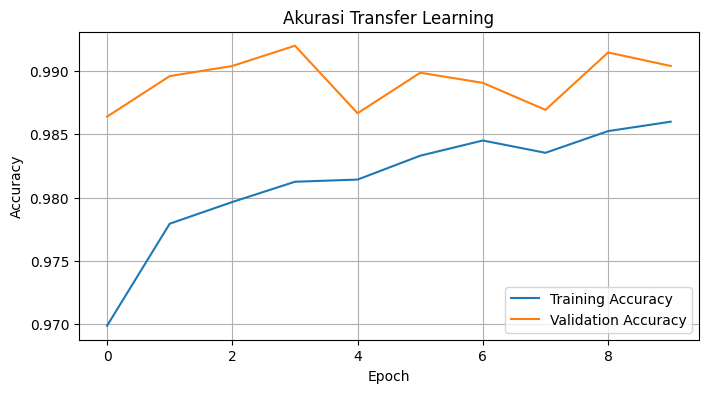

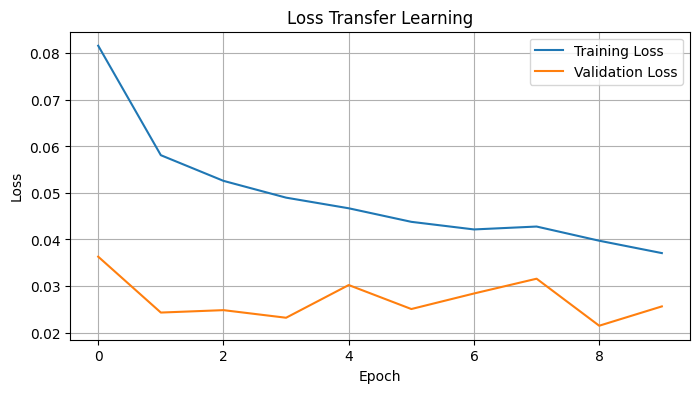

In [33]:
# Plot akurasi
plt.figure(figsize=(8, 4))
plt.plot(history_tl.history['accuracy'], label='Training Accuracy')
plt.plot(history_tl.history['val_accuracy'], label='Validation Accuracy')
plt.title('Akurasi Transfer Learning')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot loss
plt.figure(figsize=(8, 4))
plt.plot(history_tl.history['loss'], label='Training Loss')
plt.plot(history_tl.history['val_loss'], label='Validation Loss')
plt.title('Loss Transfer Learning')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Grafik akurasi menunjukkan apakah model mampu belajar membedakan cat dan dog dengan semakin baik seiring bertambahnya epoch. Grafik loss menunjukkan apakah kesalahan model semakin kecil atau tidak. Jika training accuracy naik tetapi validation accuracy stagnan, maka model mulai overfitting. Sebaliknya, jika keduanya naik secara seimbang dan loss turun stabil, maka model memiliki kemampuan generalisasi yang lebih baik. Grafik ini akan sangat berguna untuk analisis pada laporan akhir.

### 15. Confusion Matrix untuk Transfer Learning

Confusion matrix digunakan untuk mengevaluasi performa model transfer learning secara lebih rinci. Matriks ini menunjukkan jumlah prediksi yang benar dan salah pada masing-masing kelas sehingga dapat diketahui pola kesalahan yang dilakukan model.

118/118 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step


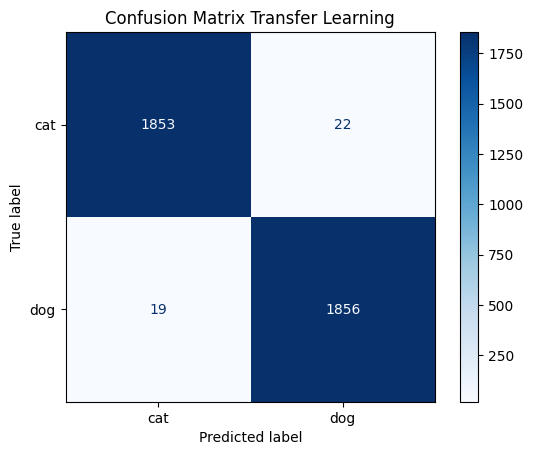

Confusion Matrix Transfer Learning:
[[1853   22]
 [  19 1856]]


In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Prediksi probabilitas
y_pred_prob_tl = model_tl.predict(test_generator)

# Konversi probabilitas menjadi label biner
y_pred_tl = (y_pred_prob_tl > 0.5).astype(int).flatten()

# Label aktual
y_true_tl = test_generator.classes

# Confusion Matrix
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)

# Visualisasi
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tl,
    display_labels=['cat', 'dog']
)

disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix Transfer Learning')
plt.show()

print("Confusion Matrix Transfer Learning:")
print(cm_tl)

Confusion matrix memberikan informasi yang lebih detail dibandingkan accuracy. Nilai pada diagonal utama menunjukkan jumlah prediksi yang benar, sedangkan nilai di luar diagonal menunjukkan kesalahan klasifikasi. Dengan confusion matrix, dapat dianalisis apakah model memiliki kecenderungan lebih baik dalam mengenali kelas cat atau kelas dog, serta mengidentifikasi pola kesalahan yang masih sering terjadi.

### 16. Classification Report

Selain confusion matrix, classification report digunakan untuk memperoleh metrik evaluasi yang lebih lengkap, yaitu precision, recall, dan F1-score pada masing-masing kelas.

In [35]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true_tl,
        y_pred_tl,
        target_names=['cat', 'dog']
    )
)

              precision    recall  f1-score   support

         cat       0.99      0.99      0.99      1875
         dog       0.99      0.99      0.99      1875

    accuracy                           0.99      3750
   macro avg       0.99      0.99      0.99      3750
weighted avg       0.99      0.99      0.99      3750



Classification report memberikan evaluasi yang lebih komprehensif dibandingkan accuracy saja. Precision menunjukkan seberapa banyak prediksi suatu kelas yang benar, recall menunjukkan kemampuan model menemukan seluruh data pada kelas tersebut, sedangkan F1-score merupakan kombinasi antara precision dan recall. Metrik ini sangat berguna ketika ingin menilai performa model secara lebih objektif.

### 17. Contoh Prediksi Benar dan Salah pada Transfer Learning

Visualisasi prediksi benar dan salah digunakan untuk memahami perilaku model secara visual. Dengan melihat contoh-contoh hasil prediksi, dapat diketahui karakteristik gambar yang mudah maupun sulit dikenali oleh model.

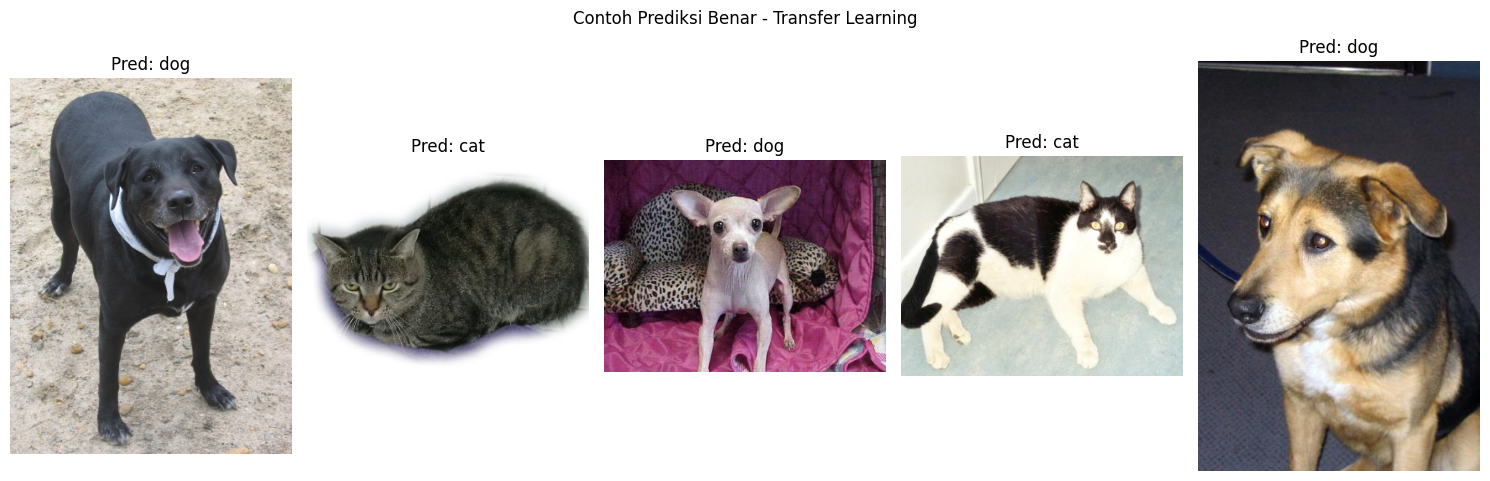

In [36]:
# Reset generator agar urutan data konsisten
test_generator.reset()

# Ambil semua file path test
test_paths = df_test["filepath"].values

# Indeks prediksi benar dan salah
correct_idx = np.where(y_pred_tl == y_true_tl)[0]
wrong_idx = np.where(y_pred_tl != y_true_tl)[0]

label_names = {0: "cat", 1: "dog"}

# Contoh prediksi benar
plt.figure(figsize=(15,5))

for i, idx in enumerate(correct_idx[:5]):
    img = plt.imread(test_paths[idx])

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(
        f"Pred: {label_names[y_pred_tl[idx]]}"
    )
    plt.axis("off")

plt.suptitle("Contoh Prediksi Benar - Transfer Learning")
plt.tight_layout()
plt.show()

**Menampilkan prediksi yang salah**

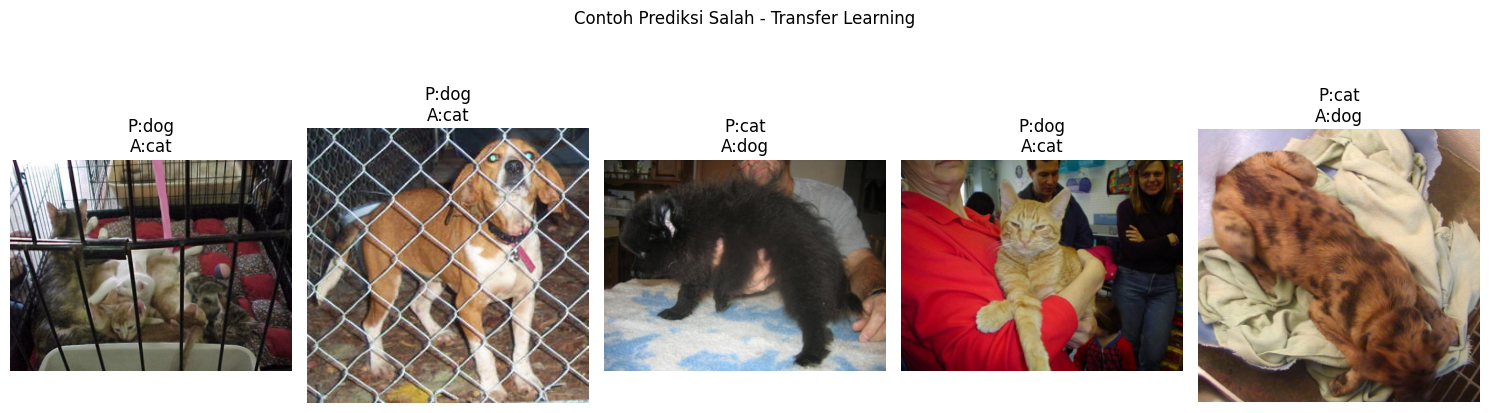

In [37]:
plt.figure(figsize=(15,5))

for i, idx in enumerate(wrong_idx[:5]):
    img = plt.imread(test_paths[idx])

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(
        f"P:{label_names[y_pred_tl[idx]]}\nA:{label_names[y_true_tl[idx]]}"
    )
    plt.axis("off")

plt.suptitle("Contoh Prediksi Salah - Transfer Learning")
plt.tight_layout()
plt.show()

Contoh prediksi benar menunjukkan gambar yang dapat dikenali dengan baik oleh model transfer learning. Sebaliknya, contoh prediksi salah memperlihatkan kondisi yang masih sulit diklasifikasikan, misalnya karena pose objek yang tidak umum, latar belakang yang kompleks, pencahayaan yang kurang baik, atau kemiripan visual antara kedua kelas. Analisis visual ini akan membantu menjelaskan kekuatan dan kelemahan model pada bagian pembahasan laporan.

### 18. Fine-Tuning MobileNetV2

Setelah model transfer learning dilatih dengan strategi feature extraction, tahap berikutnya adalah fine-tuning. Pada tahap ini, sebagian layer terakhir dari pretrained model dibuka kembali untuk dilatih agar fitur yang dipelajari lebih sesuai dengan karakteristik dataset Cats vs Dogs.

In [38]:
# Buka kembali base model untuk fine-tuning
base_model.trainable = True

# Freeze semua layer kecuali beberapa layer terakhir
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Umumnya BatchNormalization lebih stabil jika tetap dibekukan
for layer in base_model.layers[-20:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Re-compile dengan learning rate kecil
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callback untuk mencegah overfitting dan menstabilkan training
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7
    )
]

history_tl_ft = model_tl.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
195/547 ━━━━━━━━━━━━━━━━━━━━ 10:45 2s/step - accuracy: 0.9824 - loss: 0.0459

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


547/547 ━━━━━━━━━━━━━━━━━━━━ 1213s 2s/step - accuracy: 0.9871 - loss: 0.0344 - val_accuracy: 0.9875 - val_loss: 0.0298 - learning_rate: 1.0000e-05
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 1201s 2s/step - accuracy: 0.9885 - loss: 0.0313 - val_accuracy: 0.9912 - val_loss: 0.0241 - learning_rate: 1.0000e-05
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 1300s 2s/step - accuracy: 0.9898 - loss: 0.0262 - val_accuracy: 0.9901 - val_loss: 0.0237 - learning_rate: 1.0000e-05
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 1288s 2s/step - accuracy: 0.9903 - loss: 0.0262 - val_accuracy: 0.9907 - val_loss: 0.0222 - learning_rate: 1.0000e-05
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 1186s 2s/step - accuracy: 0.9908 - loss: 0.0238 - val_accuracy: 0.9909 - val_loss: 0.0241 - learning_rate: 1.0000e-05
Epoch 6/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 1181s 2s/step - accuracy: 0.9917 - loss: 0.0222 - val_accuracy: 0.9915 - val_loss: 0.0251 - learning_rate: 1.0000e-05
Epoch 7/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 1194s 2s/step - accurac

Fine-tuning dilakukan dengan membuka sebagian layer terakhir dari MobileNetV2 agar model dapat menyesuaikan fitur yang telah dipelajari dari ImageNet dengan pola visual pada dataset Cats vs Dogs. Learning rate dibuat sangat kecil karena pada tahap fine-tuning kita tidak ingin mengubah bobot pretrained model terlalu drastis. Callback EarlyStopping digunakan untuk menghentikan training ketika performa validation tidak membaik, sedangkan ReduceLROnPlateau membantu menurunkan learning rate secara otomatis ketika proses belajar mulai stagnan. Strategi ini biasanya menghasilkan performa yang lebih baik dibanding feature extraction saja, terutama jika dataset memiliki karakteristik yang cukup spesifik.

### 19. Evaluasi Model Setelah Fine-Tuning

Setelah fine-tuning selesai, model diuji kembali menggunakan data testing untuk melihat apakah penyesuaian layer terakhir benar-benar meningkatkan performa model.

In [39]:
test_loss_tl_ft, test_acc_tl_ft = model_tl.evaluate(test_generator, verbose=0)

print("Test Loss Fine-Tuned TL :", test_loss_tl_ft)
print("Test Accuracy Fine-Tuned TL :", test_acc_tl_ft)

Test Loss Fine-Tuned TL : 0.03040330857038498
Test Accuracy Fine-Tuned TL : 0.9898666739463806


Hasil evaluasi pada test set digunakan untuk melihat performa akhir model setelah fine-tuning. Jika akurasi meningkat dan loss menurun dibandingkan hasil feature extraction, maka fine-tuning berhasil memperbaiki kemampuan model dalam mengenali pola pada dataset target. Nilai ini nanti akan dipakai dalam tabel perbandingan akhir antara CNN from Scratch, feature extraction, dan fine-tuning.

### 20. Visualisasi Akurasi dan Loss Setelah Fine-Tuning

Grafik training dan validation accuracy serta loss setelah fine-tuning digunakan untuk melihat apakah proses pembelajaran menjadi lebih baik dibandingkan tahap feature extraction.

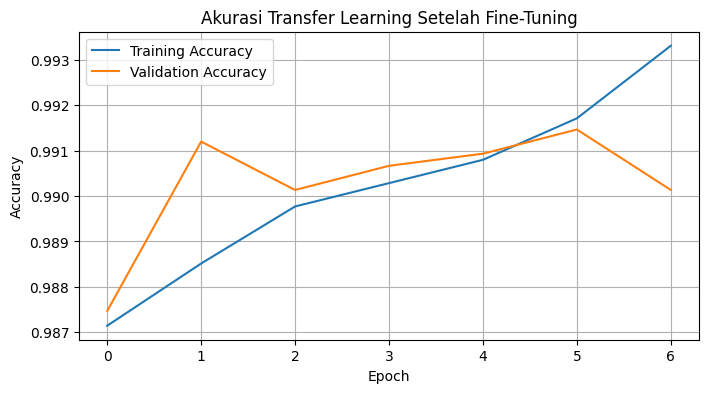

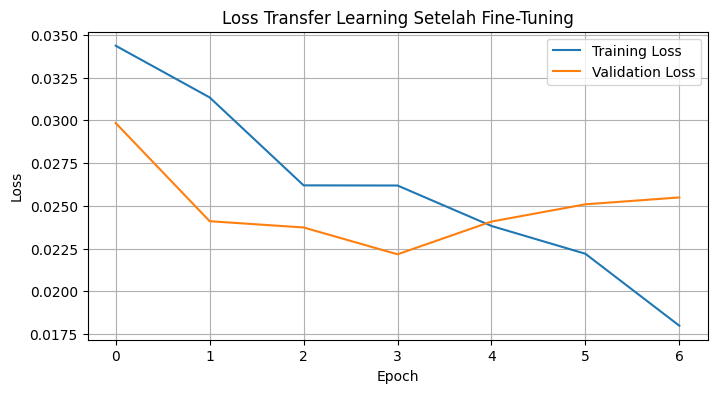

In [40]:
# Plot akurasi fine-tuning
plt.figure(figsize=(8, 4))
plt.plot(history_tl_ft.history['accuracy'], label='Training Accuracy')
plt.plot(history_tl_ft.history['val_accuracy'], label='Validation Accuracy')
plt.title('Akurasi Transfer Learning Setelah Fine-Tuning')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot loss fine-tuning
plt.figure(figsize=(8, 4))
plt.plot(history_tl_ft.history['loss'], label='Training Loss')
plt.plot(history_tl_ft.history['val_loss'], label='Validation Loss')
plt.title('Loss Transfer Learning Setelah Fine-Tuning')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Grafik ini memperlihatkan apakah fine-tuning membuat model belajar lebih stabil dan lebih adaptif terhadap dataset target. Jika validation accuracy ikut naik dan validation loss turun, maka fine-tuning memberikan manfaat nyata. Sebaliknya, jika gap antara training dan validation semakin besar, maka model mulai overfitting dan perlu penyesuaian pada jumlah layer yang dibuka, learning rate, atau jumlah epoch.

##Perbandingan Model

In [41]:
#CNN from Scratch
#Testing Accuracy
print(test_acc_cnn)
#Testing Loss
print(test_loss_cnn)
#Training Accuracy Terakhir
history_cnn.history['accuracy'][-1]
#Validation Accuracy Terakhir
history_cnn.history['val_accuracy'][-1]
#Training Loss Terakhir
history_cnn.history['loss'][-1]
#Validation Loss Terakhir
history_cnn.history['val_loss'][-1]

#Transfer Learning (Feature Extraction)
#Testing Accuracy
print(test_acc_tl)
#Testing Loss
print(test_loss_tl)
#Training Accuracy Terakhir
history_tl.history['accuracy'][-1]
#Validation Accuracy Terakhir
history_tl.history['val_accuracy'][-1]
#Training Loss Terakhir
history_tl.history['loss'][-1]
#Validation Loss Terakhir
history_tl.history['val_loss'][-1]

#Transfer Learning (Fine-Tuning)
#Testing Accuracy
print(test_acc_tl_ft)
#Testing Loss
print(test_loss_tl_ft)
#Training Accuracy Terakhir
history_tl_ft.history['accuracy'][-1]
#Validation Accuracy Terakhir
history_tl_ft.history['val_accuracy'][-1]
#Training Loss Terakhir
history_tl_ft.history['loss'][-1]
#Validation Loss Terakhir
history_tl_ft.history['val_loss'][-1]

0.7788888812065125
1.2913576364517212
0.9890666604042053
0.03081938996911049
0.9898666739463806
0.03040330857038498


0.02549276500940323